In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score, cohen_kappa_score, root_mean_squared_error, median_absolute_error, explained_variance_score
from pmdarima.arima import auto_arima
from joblib import Parallel, delayed
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
df = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'id3_prices.csv'), index_col=0, parse_dates=True)
df_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'predictions.csv'), index_col=0, parse_dates=True)
df_pca_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'pca_predictions.csv'), index_col=0, parse_dates=True)
df_arima_results = pd.read_csv(os.path.join(os.path.dirname(__file__), '..', 'data', 'arima_predictions.csv'), index_col=0, parse_dates=True)

In [ ]:
df_predicted_returns = (df_results - df.shift(1)).dropna()
df_pca_predicted_returns = (df_pca_results - df.shift(1)).dropna()
df_arima_predicted_returns = (df_arima_results - df.shift(1)).dropna()
df_actual_returns = df.diff().reindex(df_predicted_returns.index)
naive_predicted_returns = df.shift(1).diff().reindex(df_predicted_returns.index)

In [ ]:
# Ensure all DataFrames have the same index
common_index = df_predicted_returns.index.intersection(df_actual_returns.index).intersection(df_pca_predicted_returns.index).intersection(df_arima_predicted_returns.index).intersection(naive_predicted_returns.index)
df_predicted_returns = df_predicted_returns.loc[common_index]
df_pca_predicted_returns = df_pca_predicted_returns.loc[common_index]
df_arima_predicted_returns = df_arima_predicted_returns.loc[common_index]
df_actual_returns = df_actual_returns.loc[common_index]
naive_predicted_returns = naive_predicted_returns.loc[common_index]

In [ ]:
# Flatten the returns DataFrames for metric calculation
predicted_returns_flat = df_predicted_returns.values.flatten()
actual_returns_flat = df_actual_returns.values.flatten()

# Remove NaN values for metric calculation
mask = ~(np.isnan(predicted_returns_flat) | np.isnan(actual_returns_flat))
print("Dropping", np.sum(~mask), "NaN values from the returns data.")
predicted_clean = predicted_returns_flat[mask]
actual_clean = actual_returns_flat[mask]

# Calculate R² score
r2 = r2_score(actual_clean, predicted_clean)

# Mean Absolute Error
mae_returns = np.mean(np.abs(predicted_clean - actual_clean))
print(f"Mean Absolute Error: {mae_returns:.4f}")

# For classification metrics, convert returns to directional predictions
predicted_direction = np.sign(predicted_clean)
actual_direction = np.sign(actual_clean)

# Calculate accuracy
accuracy = accuracy_score(actual_direction, predicted_direction)
print(f"Direction Accuracy: {accuracy:.4f}")

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(actual_direction, predicted_direction)
print(f"Cohen's Kappa: {kappa:.4f}")

# Hit Rate (percentage of predictions within 1 standard deviation)
std_actual = np.std(actual_clean)
hit_rate = np.mean(np.abs(predicted_clean - actual_clean) <= std_actual)
print(f"Hit Rate (within 1 std): {hit_rate:.4f}")

# Calculate RMSE
rmse = root_mean_squared_error(actual_clean, predicted_clean)
print(f"RMSE: {rmse:.4f}")

# Calculate Median Absolute Error
mae = median_absolute_error(actual_clean, predicted_clean)
print(f"Median Absolute Error: {mae:.4f}")

# Calculate Spearman rank correlation coefficient
spearman_corr, _ = spearmanr(actual_clean, predicted_clean)
print(f"Spearman Correlation: {spearman_corr:.4f}")

# Calculate metrics for naive predictions
naive_returns_flat = naive_predicted_returns.values.flatten()
naive_mask = ~(np.isnan(naive_returns_flat) | np.isnan(actual_returns_flat))
naive_clean = naive_returns_flat[naive_mask]
actual_clean_naive = actual_returns_flat[naive_mask]

# Naive metrics
r2_naive = r2_score(actual_clean_naive, naive_clean)
mae_naive = np.mean(np.abs(naive_clean - actual_clean_naive))
rmse_naive = root_mean_squared_error(actual_clean_naive, naive_clean)
medae_naive = median_absolute_error(actual_clean_naive, naive_clean)
spearman_naive, _ = spearmanr(actual_clean_naive, naive_clean)

naive_direction = np.sign(naive_clean)
actual_direction_naive = np.sign(actual_clean_naive)
accuracy_naive = accuracy_score(actual_direction_naive, naive_direction)
kappa_naive = cohen_kappa_score(actual_direction_naive, naive_direction)

std_actual_naive = np.std(actual_clean_naive)
hit_rate_naive = np.mean(np.abs(naive_clean - actual_clean_naive) <= std_actual_naive)

# Calculate metrics for PCA predictions
pca_returns_flat = df_pca_predicted_returns.values.flatten()
pca_mask = ~(np.isnan(pca_returns_flat) | np.isnan(actual_returns_flat))
pca_clean = pca_returns_flat[pca_mask]
actual_clean_pca = actual_returns_flat[pca_mask]

# PCA metrics
r2_pca = r2_score(actual_clean_pca, pca_clean)
mae_pca = np.mean(np.abs(pca_clean - actual_clean_pca))
rmse_pca = root_mean_squared_error(actual_clean_pca, pca_clean)
medae_pca = median_absolute_error(actual_clean_pca, pca_clean)
spearman_pca, _ = spearmanr(actual_clean_pca, pca_clean)

pca_direction = np.sign(pca_clean)
actual_direction_pca = np.sign(actual_clean_pca)
accuracy_pca = accuracy_score(actual_direction_pca, pca_direction)
kappa_pca = cohen_kappa_score(actual_direction_pca, pca_direction)

std_actual_pca = np.std(actual_clean_pca)
hit_rate_pca = np.mean(np.abs(pca_clean - actual_clean_pca) <= std_actual_pca)

# Calculate metrics for ARIMA predictions
arima_returns_flat = df_arima_predicted_returns.values.flatten()
arima_mask = ~(np.isnan(arima_returns_flat) | np.isnan(actual_returns_flat))
arima_clean = arima_returns_flat[arima_mask]
actual_clean_arima = actual_returns_flat[arima_mask]

# ARIMA metrics
r2_arima = r2_score(actual_clean_arima, arima_clean)
mae_arima = np.mean(np.abs(arima_clean - actual_clean_arima))
rmse_arima = root_mean_squared_error(actual_clean_arima, arima_clean)
medae_arima = median_absolute_error(actual_clean_arima, arima_clean)
spearman_arima, _ = spearmanr(actual_clean_arima, arima_clean)

arima_direction = np.sign(arima_clean)
actual_direction_arima = np.sign(actual_clean_arima)
accuracy_arima = accuracy_score(actual_direction_arima, arima_direction)
kappa_arima = cohen_kappa_score(actual_direction_arima, arima_direction)

std_actual_arima = np.std(actual_clean_arima)
hit_rate_arima = np.mean(np.abs(arima_clean - actual_clean_arima) <= std_actual_arima)

# Create comparison table including PCA and ARIMA
print("\n" + "="*90)
print("MODEL vs PCA vs ARIMA vs NAIVE COMPARISON")
print("="*90)
comparison_metrics = pd.DataFrame({
    'ICA Model': [r2, mae_returns, rmse, mae, accuracy, kappa, hit_rate, spearman_corr],
    'PCA Model': [r2_pca, mae_pca, rmse_pca, medae_pca, accuracy_pca, kappa_pca, hit_rate_pca, spearman_pca],
    'ARIMA Model': [r2_arima, mae_arima, rmse_arima, medae_arima, accuracy_arima, kappa_arima, hit_rate_arima, spearman_arima],
    'Naive': [r2_naive, mae_naive, rmse_naive, medae_naive, accuracy_naive, kappa_naive, hit_rate_naive, spearman_naive],
}, index=['R²', 'MAE', 'RMSE', 'Median AE', 'Direction Accuracy', 'Cohen\'s Kappa', 'Hit Rate', 'Spearman Corr'])

# Define which metrics are "higher is better" vs "lower is better"
higher_is_better = ['R²', 'Direction Accuracy', 'Cohen\'s Kappa', 'Hit Rate', 'Spearman Corr']
lower_is_better = ['MAE', 'RMSE', 'Median AE']

# Calculate improvements
for model in ['ICA Model', 'PCA Model', 'ARIMA Model']:
    comparison_metrics[f'{model} vs Naive (%)'] = 0.0
    
    for metric in comparison_metrics.index:
        model_val = comparison_metrics.loc[metric, model]
        naive_val = comparison_metrics.loc[metric, 'Naive']
        
        if metric in higher_is_better:
            rel_improvement = ((model_val - naive_val) / abs(naive_val)) * 100 if naive_val != 0 else 0
        else:
            rel_improvement = ((naive_val - model_val) / abs(naive_val)) * 100 if naive_val != 0 else 0
        
        comparison_metrics.loc[metric, f'{model} vs Naive (%)'] = round(rel_improvement, 2)

print(comparison_metrics.round(4))

Dropping 0 NaN values from the returns data.
Mean Absolute Error: 29.3147
Direction Accuracy: 0.6448
Cohen's Kappa: 0.2888
Hit Rate (within 1 std): 0.8482
RMSE: 53.9995
Median Absolute Error: 14.1031
Spearman Correlation: 0.3862

MODEL vs PCA vs ARIMA vs NAIVE COMPARISON
                    ICA Model  PCA Model  ARIMA Model    Naive  \
R²                    -0.0126    -5.3310       0.2246  -1.5823   
MAE                   29.3147    92.5335      25.5002  45.4103   
RMSE                  53.9995   135.0228      47.2548  86.2335   
Median AE             14.1031    61.4922      12.8521  22.8600   
Direction Accuracy     0.6448     0.5443       0.6480   0.4192   
Cohen's Kappa          0.2888     0.0717       0.2951  -0.1603   
Hit Rate               0.8482     0.4383       0.8721   0.7422   
Spearman Corr          0.3862     0.2368       0.3985  -0.2236   

                    ICA Model vs Naive (%)  PCA Model vs Naive (%)  \
R²                                   99.20                 -236

In [ ]:
# Quarterly analysis
def calculate_quarterly_metrics(predicted_df, actual_df, label):
    """Calculate metrics for quarterly intervals"""
    quarterly_results = []
    
    # Align indices
    common_index = predicted_df.index.intersection(actual_df.index)
    predicted_aligned = predicted_df.loc[common_index]
    actual_aligned = actual_df.loc[common_index]
    
    # Group by quarters
    quarters = predicted_aligned.groupby(pd.Grouper(freq='Q'))
    
    for quarter_end, quarter_data in quarters:
        if len(quarter_data) == 0:
            continue
            
        quarter_actual = actual_aligned.loc[quarter_data.index]
        
        # Flatten and clean data
        pred_flat = quarter_data.values.flatten()
        actual_flat = quarter_actual.values.flatten()
        mask = ~(np.isnan(pred_flat) | np.isnan(actual_flat))
        
        if np.sum(mask) < 10:  # Skip if too few data points
            continue
            
        pred_clean = pred_flat[mask]
        actual_clean = actual_flat[mask]
        
        # Calculate metrics
        r2_q = r2_score(actual_clean, pred_clean)
        mae_q = np.mean(np.abs(pred_clean - actual_clean))
        rmse_q = root_mean_squared_error(actual_clean, pred_clean)
        spearman_q, _ = spearmanr(actual_clean, pred_clean)
        
        pred_dir = np.sign(pred_clean)
        actual_dir = np.sign(actual_clean)
        accuracy_q = accuracy_score(actual_dir, pred_dir)
        
        quarterly_results.append({
            'Quarter': quarter_end,
            'Model': label,
            'R²': r2_q,
            'MAE': mae_q,
            'RMSE': rmse_q,
            'Direction_Accuracy': accuracy_q,
            'Spearman': spearman_q,
            'N_Observations': len(pred_clean)
        })
    
    return quarterly_results

# Calculate quarterly metrics for all models
quarterly_metrics = []
quarterly_metrics.extend(calculate_quarterly_metrics(df_predicted_returns, df_actual_returns, 'ICA'))
quarterly_metrics.extend(calculate_quarterly_metrics(df_pca_predicted_returns, df_actual_returns, 'PCA'))
quarterly_metrics.extend(calculate_quarterly_metrics(df_arima_predicted_returns, df_actual_returns, 'ARIMA'))
quarterly_metrics.extend(calculate_quarterly_metrics(naive_predicted_returns, df_actual_returns, 'Naive'))

quarterly_df = pd.DataFrame(quarterly_metrics)

print("\nQuarterly Performance:")
print(quarterly_df.pivot_table(index='Quarter', columns='Model', values=['R²', 'MAE', 'Direction_Accuracy', 'Spearman']).round(4))


Quarterly Performance:
           Direction_Accuracy                              MAE            \
Model                   ARIMA     ICA   Naive     PCA    ARIMA       ICA   
Quarter                                                                    
2017-12-31             0.5260  0.5104  0.3542  0.6250  20.1580   24.8881   
2018-03-31             0.6935  0.7014  0.3667  0.5546  10.8889   11.0875   
2018-06-30             0.6566  0.6479  0.3947  0.5417   9.6915   10.3373   
2018-09-30             0.6436  0.6273  0.4203  0.5249   9.8641   11.1422   
2018-12-31             0.6816  0.6870  0.3954  0.5444  12.4402   12.9861   
2019-03-31             0.6773  0.6736  0.4204  0.5722  11.6867   12.0982   
2019-06-30             0.6484  0.6552  0.4093  0.5302  10.0571    9.8569   
2019-09-30             0.6662  0.6603  0.4226  0.5122   8.3519    8.2414   
2019-12-31             0.6635  0.6535  0.4330  0.5643   9.6143    9.6780   
2020-03-31             0.6442  0.6557  0.4139  0.5728  10.7345  

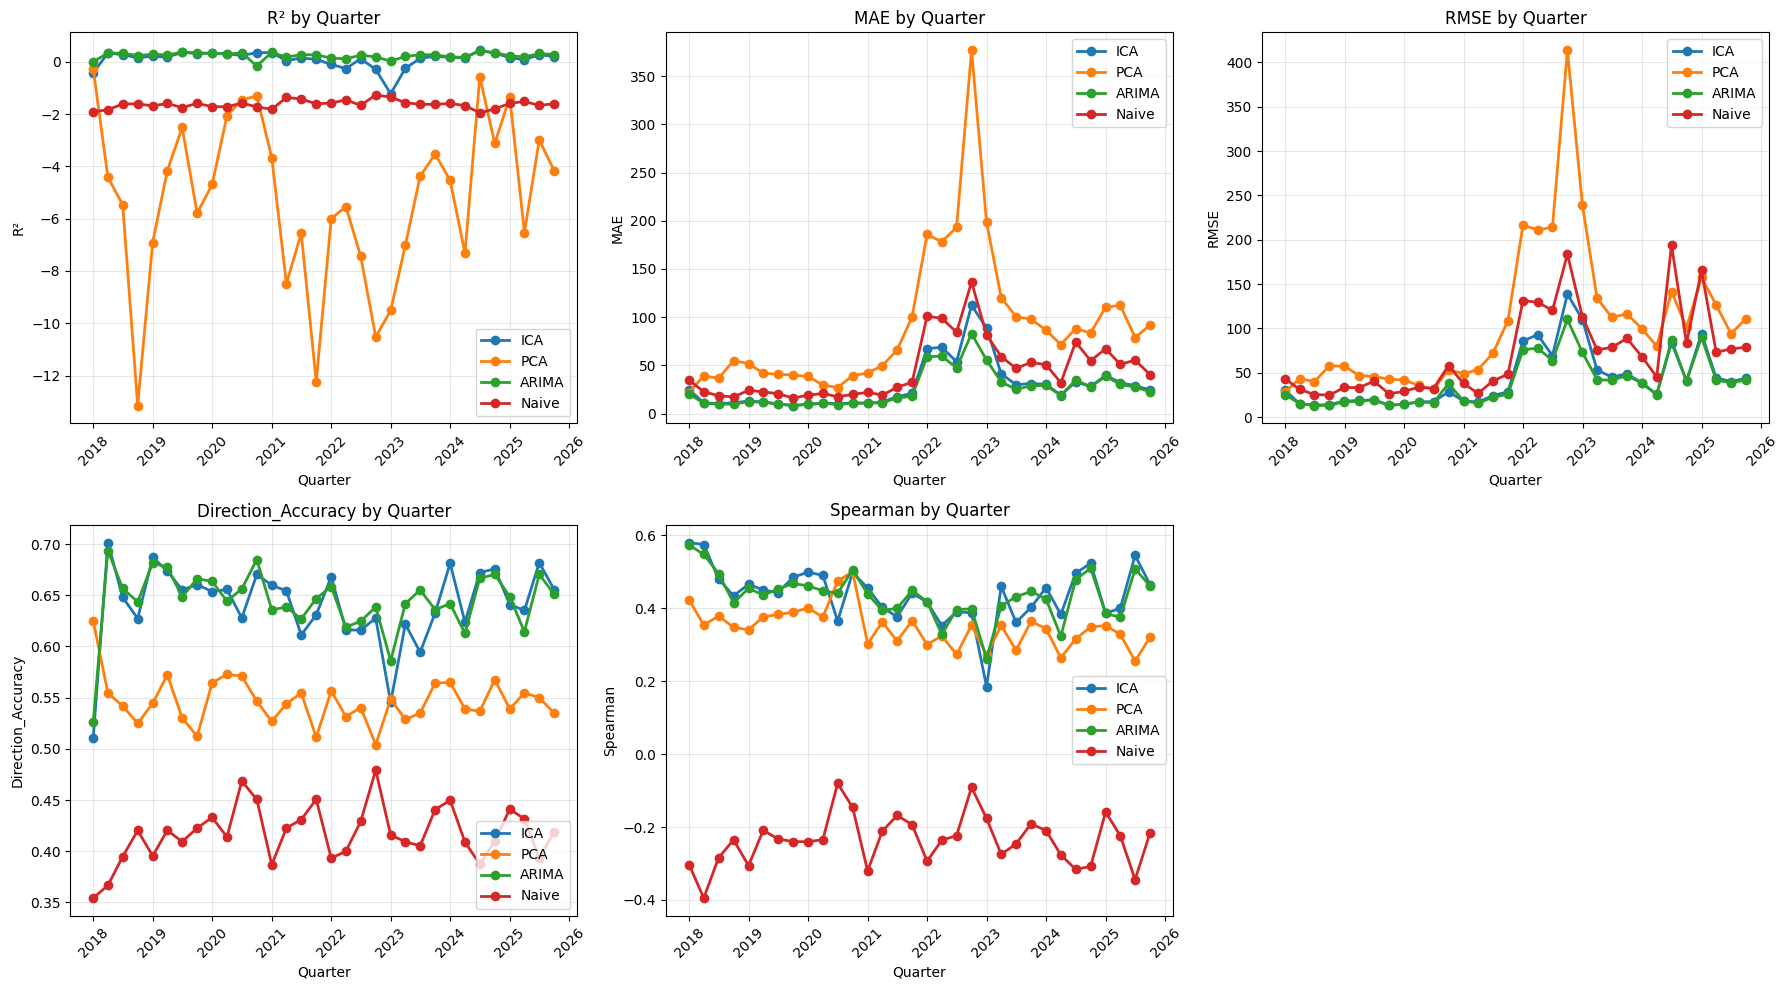

In [ ]:
# Plot quarterly progression
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['R²', 'MAE', 'RMSE', 'Direction_Accuracy', 'Spearman']
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    for model in ['ICA', 'PCA', 'ARIMA', 'Naive']:
        model_data = quarterly_df[quarterly_df['Model'] == model]
        ax.plot(model_data['Quarter'], model_data[metric], marker='o', label=model, linewidth=2)
    
    ax.set_title(f'{metric} by Quarter')
    ax.set_xlabel('Quarter')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide the last subplot if not used
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

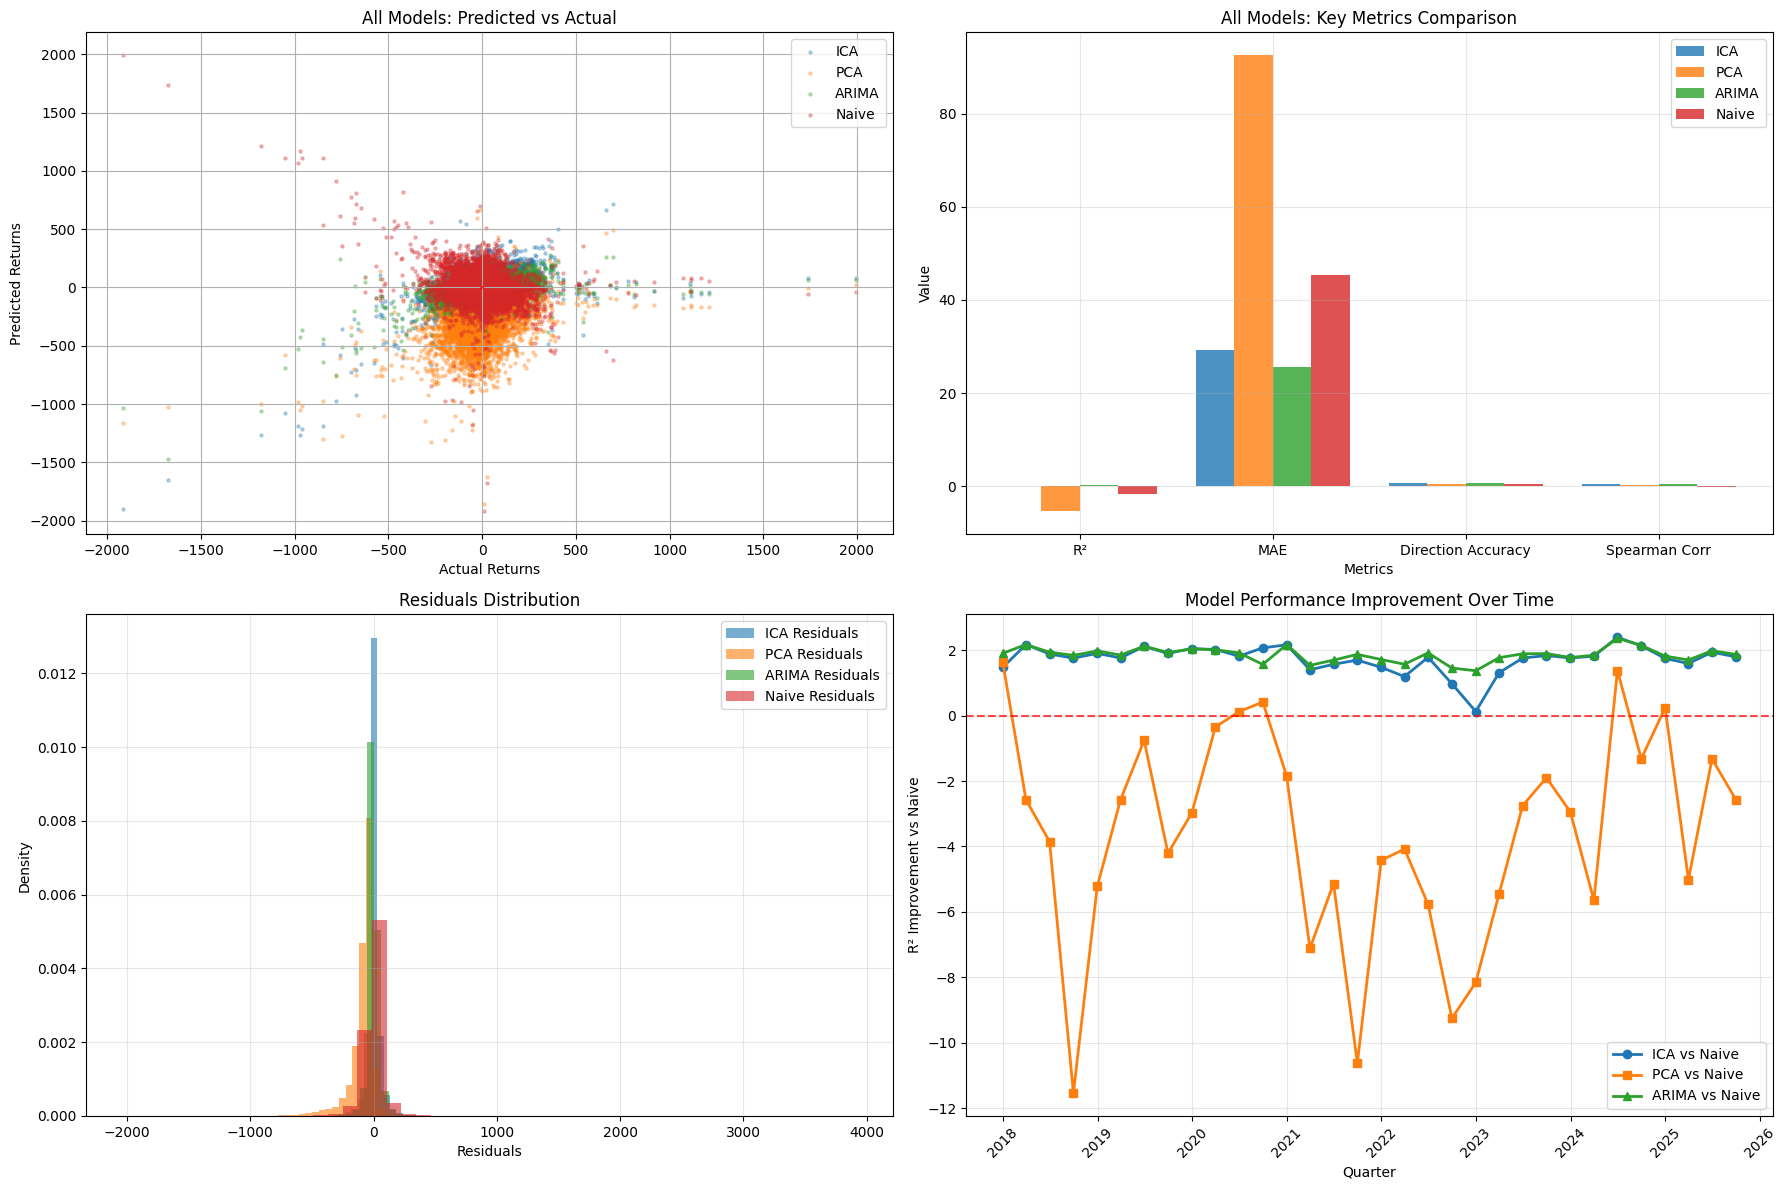

In [ ]:
# Plot comparison of all models
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Scatter plot comparison
axes[0,0].scatter(actual_clean, predicted_clean, alpha=0.3, label='ICA', s=5)
axes[0,0].scatter(actual_clean_pca, pca_clean, alpha=0.3, label='PCA', s=5)
axes[0,0].scatter(actual_clean_arima, arima_clean, alpha=0.3, label='ARIMA', s=5)
axes[0,0].scatter(actual_clean_naive, naive_clean, alpha=0.3, label='Naive', s=5)
axes[0,0].plot([-10, 10], [-10, 10], 'r--', alpha=0.8)
axes[0,0].set_xlabel('Actual Returns')
axes[0,0].set_ylabel('Predicted Returns')
axes[0,0].set_title('All Models: Predicted vs Actual')
axes[0,0].legend()
axes[0,0].grid(True)

# Bar chart of key metrics
metrics_names = ['R²', 'MAE', 'Direction Accuracy', 'Spearman Corr']
ica_values = [r2, mae_returns, accuracy, spearman_corr]
pca_values = [r2_pca, mae_pca, accuracy_pca, spearman_pca]
arima_values = [r2_arima, mae_arima, accuracy_arima, spearman_arima]
naive_values = [r2_naive, mae_naive, accuracy_naive, spearman_naive]

x = np.arange(len(metrics_names))
width = 0.2

axes[0,1].bar(x - width*1.5, ica_values, width, label='ICA', alpha=0.8)
axes[0,1].bar(x - width/2, pca_values, width, label='PCA', alpha=0.8)
axes[0,1].bar(x + width/2, arima_values, width, label='ARIMA', alpha=0.8)
axes[0,1].bar(x + width*1.5, naive_values, width, label='Naive', alpha=0.8)
axes[0,1].set_xlabel('Metrics')
axes[0,1].set_ylabel('Value')
axes[0,1].set_title('All Models: Key Metrics Comparison')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(metrics_names)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Residuals comparison
ica_residuals = predicted_clean - actual_clean
pca_residuals = pca_clean - actual_clean_pca
arima_residuals = arima_clean - actual_clean_arima
naive_residuals = naive_clean - actual_clean_naive

axes[1,0].hist(ica_residuals, bins=50, alpha=0.6, label='ICA Residuals', density=True)
axes[1,0].hist(pca_residuals, bins=50, alpha=0.6, label='PCA Residuals', density=True)
axes[1,0].hist(arima_residuals, bins=50, alpha=0.6, label='ARIMA Residuals', density=True)
axes[1,0].hist(naive_residuals, bins=50, alpha=0.6, label='Naive Residuals', density=True)
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Residuals Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Performance improvement over time
quarterly_pivot = quarterly_df.pivot_table(index='Quarter', columns='Model', values='R²')
improvement_vs_naive = quarterly_pivot.subtract(quarterly_pivot['Naive'], axis=0)

axes[1,1].plot(improvement_vs_naive.index, improvement_vs_naive['ICA'], marker='o', label='ICA vs Naive', linewidth=2)
axes[1,1].plot(improvement_vs_naive.index, improvement_vs_naive['PCA'], marker='s', label='PCA vs Naive', linewidth=2)
axes[1,1].plot(improvement_vs_naive.index, improvement_vs_naive['ARIMA'], marker='^', label='ARIMA vs Naive', linewidth=2)
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].set_xlabel('Quarter')
axes[1,1].set_ylabel('R² Improvement vs Naive')
axes[1,1].set_title('Model Performance Improvement Over Time')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()